In [1]:
pip install pandas scikit-learn werkzeug sqlalchemy flask_admin flask_migrate flask_rq2 flask_compress dnachisel openpyxl matplotlib

Note: you may need to restart the kernel to use updated packages.


In [42]:
import time
from io import BytesIO
from datetime import datetime, UTC, timedelta
import traceback
import json
import io
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from werkzeug.exceptions import BadRequest
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import statistics

#from app.helpers.fold_storage_manager import FoldStorageManager
from app.helpers.sequence_util import (
    get_measured_and_unmeasured_mutant_seq_ids,
    get_loci_set,
    process_and_validate_evolve_input_files,
)




def train_model(wt_aa_seq,raw_activity_df,raw_embedding_df,model):
    activity_df, embedding_df = process_and_validate_evolve_input_files(
                wt_aa_seq, raw_activity_df, raw_embedding_df
            )
    measured_mutants, unmeasured_mutants = (
                get_measured_and_unmeasured_mutant_seq_ids(activity_df, embedding_df)
            )
    X_train = np.vstack(
                [json.loads(x) for x in embedding_df.loc[activity_df.index].embedding]
            )
    y_train = activity_df.activity.to_numpy()
    #model = RandomForestRegressor(
    #    n_estimators=100,
    #    criterion="friedman_mse",
    #    max_depth=None,
    #    min_samples_split=2,
    #    min_samples_leaf=1,
    #    min_weight_fraction_leaf=0.0,
    #    max_features=1.0,
    #    max_leaf_nodes=None,
    #    min_impurity_decrease=0.0,
    #    bootstrap=True,
    #    oob_score=False,
    #    n_jobs=None,
    #    random_state=1,
    #    verbose=0,
    #    warm_start=False,
    #    ccp_alpha=0.0,
    #    max_samples=None,
    #)
    model.fit(X_train, y_train)
    try:
        all_mutants_embedding_array = np.vstack(
            [
                json.loads(x)
                for x in embedding_df.loc[
                    measured_mutants + unmeasured_mutants
                ].embedding
            ]
        )
        #print(all_mutants_embedding_array.shape)
        y_all_pred = model.predict(all_mutants_embedding_array)
        predicted_activity_df = pd.DataFrame(
            {
                "seq_id": measured_mutants + unmeasured_mutants,
                "predicted_activity": y_all_pred,
            }
        )
        predicted_activity_df.index = predicted_activity_df.seq_id
        predicted_activity_df["relevant_measured_mutants"] = (
            predicted_activity_df.seq_id.apply(
                lambda seq_id: " ".join(
                    [
                        m
                        for m in measured_mutants
                        if get_loci_set(m) & get_loci_set(seq_id)
                    ]
                )
            )
        )
        predicted_activity_df["actual_activity"] = predicted_activity_df.join(
            activity_df.groupby(level=0).activity.mean(), how="left"
        ).activity
        predicted_activity_df = predicted_activity_df.sort_values(
            "predicted_activity", ascending=False
        )
    except Exception as e:
        print(f"Failed to predict activities: {e}")
        raise
    predicted_activity_df.reset_index(drop=True,inplace=True)
    #predicted_activity_csv_path = evolve_directory / f"Round_{round_num}_predicted_activity.csv"
    #print(f"Storing predicted activities in {predicted_activity_csv_path}")
    #try:
    #    predicted_activity_df.to_csv(predicted_activity_csv_path, index=False)
    #except Exception as e:
    #    print(f"Failed to store predicted activities: {e}")
    #    raise
    return predicted_activity_df

def evaluate_predictions(predicted_activity_df,exp_activity_df,round_activity_df,num_var,round_num,evolve_directory):
    try:
        predict = predicted_activity_df["actual_activity"].isna()
        extract_predict = predicted_activity_df[predict]
        #print(extract_predict)
        top_var = extract_predict.iloc[0:num_var]
        #print(top_var)
        top_var_real = pd.merge(top_var,exp_activity_df,on='seq_id', how='inner')
        top_var_real = top_var_real[['seq_id','activity']]
        #top_var_csv_path = evolve_directory / f"Round_{round_num}_top_variants.xlsx"
        #top_var_real.to_excel(top_var_csv_path, index=False)
        next_round_activity = pd.concat([round_activity_df,top_var_real], ignore_index=True)
    except Exception as e:
        print(f"Failed to Evaluate Predictions")
        raise
    return next_round_activity

def evolve_simulation(wt_aa_seq,embeddings_path,exp_activity_file_path,num_var,model_type,quantile):
    exp_activity_df = pd.read_excel(exp_activity_file_path)
    raw_embedding_df = pd.read_csv(embeddings_path)
    raw_activity_df = exp_activity_df.sample(num_var)
    while not raw_activity_df['seq_id'].isin(raw_embedding_df['seq_id']).all():
        raw_activity_df = exp_activity_df.sample(num_var)
    #print(raw_activity_df)
    evolve_directory = Path("evolve") / Path(exp_activity_file_path).stem
    evolve_directory.mkdir(parents=True, exist_ok=True)
    #init_var_path = evolve_directory / f"Round_0_variants.xlsx"
    #raw_activity_df.to_excel(init_var_path, index=False)
    var_exp_data = [raw_activity_df.sort_values('activity',ascending=True)]
    #top_percent_df = exp_activity_df.sort_values('activity',ascending=False)
    #print(top_percent_df)
    #print('this is the sorted activity')
    top_percent_activity = exp_activity_df['activity'].quantile(quantile)
    top_percent_df = exp_activity_df[exp_activity_df['activity'] >= top_percent_activity]
    #print('There are this many top variants')
    #print(top_percent_df.shape)
    #print(f'These are the top variants')
    #print(top_percent_df)
    #print(round(len(top_percent_df)*0.51))
    i = 1
    complete = True
    top_var_per_round = []
    while complete:
        if i == 1:
            predicted_activity_df = train_model(wt_aa_seq,raw_activity_df,raw_embedding_df,model_type)
            current_round_activity_df = evaluate_predictions(predicted_activity_df,exp_activity_df,raw_activity_df,num_var,i,evolve_directory)
            #print(i)
            #print(current_round_activity_df)
        else:
            predicted_activity_df = train_model(wt_aa_seq,current_round_activity_df,raw_embedding_df,model_type)
            current_round_activity_df = evaluate_predictions(predicted_activity_df,exp_activity_df,current_round_activity_df,num_var,i,evolve_directory)
            #print(i)
            #print(top_percent_df['seq_id'].isin(current_round_activity_df['seq_id']).all())
        var_exp_data.append(current_round_activity_df.sort_values('activity',ascending=True))
        #if i == round_num:
        #    complete = False
        #    break
        num_top_var_df = pd.merge(top_percent_df,current_round_activity_df, on='seq_id')
        top_var_per_round.append(len(num_top_var_df))
        if len(num_top_var_df) >= (round(len(top_percent_df)*0.2)):
            print('test')
            complete = False
            break  
        print(f'Round {i} Evolution found {len(num_top_var_df)} top variants')
        i += 1
        #print(current_round_activity_df.shape)

        
    print(f'It took {i} rounds to get the majority of the top {quantile * 100} % of variants')
    print(top_var_per_round)
    #print(var_exp_data)
    return i, top_var_per_round
def plot_evolution(embeddings_paths, num_columns):
    num_embeddings = len(embeddings_paths)
    num_rows = (num_embeddings + num_columns -1) // num_columns


    

In [18]:
randomforest = RandomForestRegressor(
        n_estimators=100,
        criterion="friedman_mse",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_weight_fraction_leaf=0.0,
        max_features=1.0,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=None,
        random_state=1,
        verbose=0,
        warm_start=False,
        ccp_alpha=0.0,
        max_samples=None,
    )


In [6]:
embeddings_dir = '../EvolveTest'
embeddings_paths = ['kelsic_esmc_600m_wt_dms']
embeddings_path = os.path.join(embeddings_dir, embeddings_paths[0])
print(embeddings_path)

../EvolveTest\kelsic_esmc_600m_wt_dms


In [58]:
import os

wt_aa_seq = 'MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKMRKNYIRILTGDKVTVELTPYDLSKGRIVFRSR'
dataset = 'kelsic'
exp_activity_file_path = r'..\EvolveTest\Kelsic_Data_foldy.xlsx'
embeddings_dir = '../EvolveTest'
embeddings_paths = [
    'kelsic_esm1b_t33_650M_UR50S.csv',
    'kelsic_esm2_t33_650M_UR50D.csv',
    'kelsic_esm2_t36_3B_UR50D.csv',
    'kelsic_esmc_600m_wt_dms.csv'
]
model_type = randomforest
quantile = 0.80
rounds_evo = 2
num_var = 20
embeddings_rounds_to_top = {}
evo_imgs = []
for path in embeddings_paths:

    embeddings_path = os.path.join(embeddings_dir, path)
    round_to_best = []
    var_per_round = []

    for j in range(rounds_evo):

        rounds, var_sum = evolve_simulation(wt_aa_seq,embeddings_path,exp_activity_file_path,num_var,model_type,quantile)
        round_to_best.append(rounds)
        var_per_round.append(var_sum)

    avg_round = statistics.mean(round_to_best)
    vars_per_round = [np.array(x) for x in var_per_round]
    avg_var_per_round = []
    std_error_per_round = []

    for k in zip(*vars_per_round):
        avg = np.mean(k)
        std_dev = np.std(k, ddof=1)
        se = std_dev / np.sqrt(len(k))
        avg_var_per_round.append(float(avg))
        std_error_per_round.append(float(se))

    embeddings_rounds_to_top[path] = [avg_round,avg_var_per_round]
    print(avg_round)
    print(avg_var_per_round)
    evo_imgs.append([avg_var_per_round,std_error_per_round])
    
print(evo_imgs)
    
embeddings_comp_df = pd.DataFrame.from_dict(embeddings_rounds_to_top, orient='index',columns=['Median Round','Total Variants per Round'])
comp_dir = os.path.join(embeddings_dir, dataset, f'{num_var}Variant_Model_Comparisons_{quantile}.xlsx')
embeddings_comp_df.to_excel(comp_dir, index=True)






Round 1 Evolution found 17 top variants
Round 2 Evolution found 29 top variants
Round 3 Evolution found 42 top variants
Round 4 Evolution found 50 top variants
Round 5 Evolution found 57 top variants
test
It took 6 rounds to get the majority of the top 80.0 % of variants
[17, 29, 42, 50, 57, 67]
Round 1 Evolution found 12 top variants
Round 2 Evolution found 20 top variants
Round 3 Evolution found 29 top variants
Round 4 Evolution found 40 top variants
Round 5 Evolution found 51 top variants
Round 6 Evolution found 57 top variants
test
It took 7 rounds to get the majority of the top 80.0 % of variants
[12, 20, 29, 40, 51, 57, 66]
6.5
[14.5, 24.5, 35.5, 45.0, 54.0, 62.0]
Round 1 Evolution found 8 top variants
Round 2 Evolution found 14 top variants
Round 3 Evolution found 25 top variants
Round 4 Evolution found 32 top variants
Round 5 Evolution found 36 top variants
Round 6 Evolution found 41 top variants
Round 7 Evolution found 47 top variants
Round 8 Evolution found 52 top variants
Ro

ParserError: Error tokenizing data. C error: EOF inside string starting at row 1326

72.5


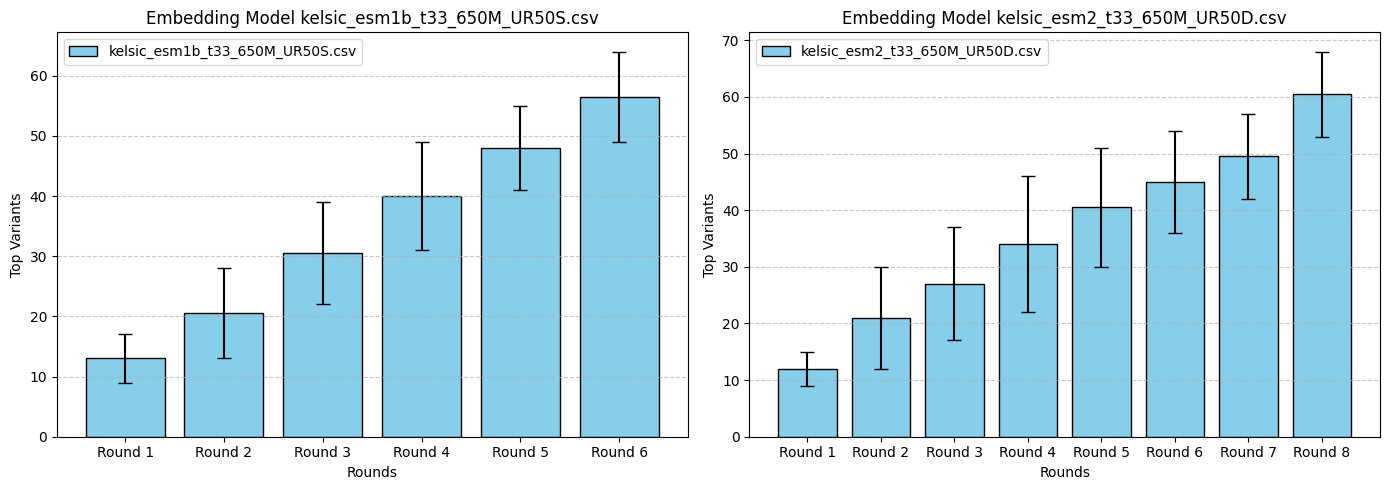

In [57]:
# Determine the number of datasets
num_imgs = len(evo_imgs)

# Calculate the number of rows and columns for the subplot grid
num_cols = 2
num_rows = (num_imgs + num_cols - 1) // num_cols  # Ceiling division

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 5 * num_rows))

# Flatten the axes array for easier iteration
if num_imgs == 1:
    axes = [axes]  # Ensure axes is a list if there's only one subplot
else:
    axes = axes.flatten()

max_y_value = 0
for means, std_errors in evo_imgs:
    max_y_value = max(max_y_value, max(means) + max(std_errors))
print(max_y_value)
# Plot each dataset
for i, (means, std_errors) in enumerate(evo_imgs):
    ax = axes[i]
    num_groups=len(means)
    x_indices = np.arange(1, num_groups + 1)

    ax.bar(x_indices, means, yerr=std_errors, capsize=5, label = embeddings_paths[i], color='skyblue', edgecolor='black')
    ax.set_xlabel('Rounds')
    ax.set_ylabel('Top Variants')
    ax.set_title(f'Embedding Model {embeddings_paths[i]}')
    ax.set_xticks(x_indices)
    ax.set_xticklabels([f'Round {k}' for k in x_indices])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.set_ylim=(0, max_y_value)

# Hide any unused subplots
for j in range(num_imgs, num_rows * num_cols):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()